This notebook assume one has activated the conda environment: `Summer2026-py311` (in the workstation).

# Opening and accessing the file

In [3]:
from pathlib import Path
# Replace this with your own path to the `SURIP2026` directory
GIT_REPO_PATH = Path.cwd().parent

import sys
sys.path.append(GIT_REPO_PATH.as_posix())
from utils import h5load

main_dir = Path("/users/shared.user/Summer2026/cogwheel_O4_gaussian_injections/PE/IntrinsicLVCPrior/")

unlensed = main_dir / "unlensed_samples/processed_samples"
images_2 = main_dir / "2_images_samples/processed_samples"
images_3 = main_dir / "3_images_samples/processed_samples"
images_4 = main_dir / "4_images_samples/processed_samples"

all_unlensed = list(unlensed.glob("*.h5"))
all_images_2 = list(images_2.glob("*.h5"))
all_images_3 = list(images_3.glob("*.h5"))
all_images_4 = list(images_4.glob("*.h5"))

In [4]:
# Show the available files in each directory
print(f"Unlensed samples: {len(all_unlensed)}")
print(f"2-images samples: {len(all_images_2)}")
print(f"3-images samples: {len(all_images_3)}")
print(f"4-images samples: {len(all_images_4)}")

Unlensed samples: 1486
2-images samples: 9925
3-images samples: 2974
4-images samples: 3978


In [5]:
# Try access the first file in the 2-images samples
target_file = all_images_2[0]
print(f"The filename is: {target_file.name}")

df = h5load(target_file)
print(f"The event name is {df.attrs['event_name']}")
print(f"The number of posterior samples is {len(df)}")

The filename is: MD_SDSS_l2_1001_1_bilby_style_samples.h5
The event name is MD_SDSS_l2_1001_1
The number of posterior samples is 13339


# Plotting

In [6]:
import matplotlib.pyplot as plt
# These are needed for recomputing the redshift
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

In [7]:
## Check the injection parameters
inj_dict = df.attrs['injection_values']
m1 = inj_dict['m1']
m2 = inj_dict['m2']
inj_dict['mass_ratio'] = m2 / m1
inj_dict['chirp_mass'] = ((m1 * m2) ** 3 / (m1 + m2)) ** 0.2
inj_dict['redshift'] = z_at_value(
    Planck18.luminosity_distance, inj_dict['d_luminosity'] * u.Mpc).value
inj_dict['chirp_mass_source'] = inj_dict['chirp_mass'] / (1 + inj_dict['redshift'])
inj_dict['chi_eff'] = (inj_dict['s1z'] + inj_dict['mass_ratio'] * inj_dict['s2z']) / (1 + inj_dict['mass_ratio'])

Text(0, 0.5, '$p(\\chi_{\\rm eff}|d)$')

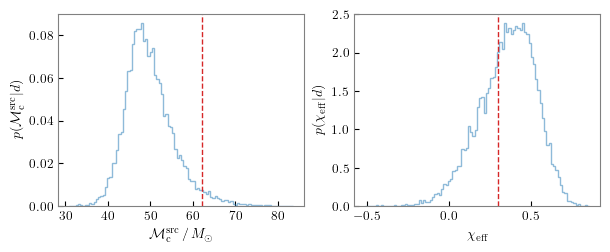

In [8]:
hist_kwargs = {"bins": 100, "density": True, "alpha": 0.5, "histtype": "step"}
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))
ax = axes[0]
ax.hist(df["chirp_mass_source"], **hist_kwargs)
ax.axvline(inj_dict['chirp_mass_source'], color="C3", linestyle="--")
ax.set_xlabel(r"${\cal M}_{\rm c}^{\rm src}\,/\,M_\odot$")
ax.set_ylabel(r"$p({\cal M}_{\rm c}^{\rm src}|d)$")
ax = axes[1]
ax.hist(df["chi_eff"], **hist_kwargs)
ax.axvline(inj_dict['chi_eff'], color="C3", linestyle="--")
ax.set_xlabel(r"$\chi_{\rm eff}$")
ax.set_ylabel(r"$p(\chi_{\rm eff}|d)$")

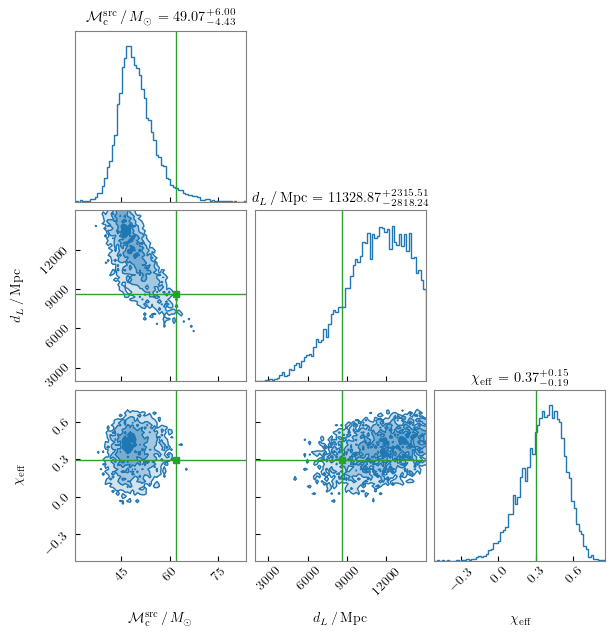

In [9]:
## Show the correlation between mass, distance and chi_eff
from corner import corner

fig = plt.figure(figsize=(6.5, 6.5))

fig = corner(df[["chirp_mass_source", "luminosity_distance", "chi_eff"]], 
       bins=70, plot_datapoints=False, fill_contours=True,
       show_titles=True, color="C0", truth_color="C2", fig=fig,
       labels=[r"${\cal M}_{\rm c}^{\rm src}\,/\,M_\odot$", r"$d_L\,/\,{\rm Mpc}$", r"$\chi_{\rm eff}$"],
       truths=[inj_dict['chirp_mass_source'], inj_dict['d_luminosity'], inj_dict['chi_eff']])

# Loading with FIGARO

In [10]:
# Need this if not running within the GitHub directory
# sys.path.append((Path.cwd().parent / "data_processing").as_posix())
from data_processing import load_data

In [11]:
# Check the options of the `load_data` function
load_data?

Signature:
load_data(
    dir_path,
    seed=False,
    par=None,
    n_samples=-1,
    cosmology='Planck18',
    volume=False,
    waveform='combined',
    snr_threshold=None,
    far_threshold=None,
    verbose=True,
    likelihood=False,
    keep_dVdz=False,
    blacklist_events=None,
)
Docstring:
Loads the data .h5/.hdf5 files (processed cogwheel posterior files).
Default cosmological parameters from Planck Collaboration (2021) in a flat Universe (https://www.aanda.org/articles/aa/pdf/2020/09/aa33910-18.pdf)
Not all GW parameters are implemented: run figaro.load.available_gw_pars() for a list of available parameters.

Arguments:
    str or Path path:       folder with data files
    bool seed:              fixes the seed to a default value (1) for reproducibility
    list-of-str par:        list with parameter(s) to extract from GW posteriors
    int n_samples:          number of samples for (random) downsampling. Default -1: all samples
    str cosmology:          set of cosmologi

In [12]:
# This will take some time to run
loaded_data, event_names = load_data(
    dir_path=images_2,
    seed=False,
    par=['m1', 'm2'],
    n_samples=-1,
)

print(event_names)
print("Total loaded events:", len(event_names))

Loading events: 100%|██████████| 9925/9925 [05:40<00:00, 29.13it/s]

['MD_SDSS_l2_1001_1' 'MD_SDSS_l2_1002_1' 'MD_SDSS_l2_1003_1' ...
 'MD_SDSS_l2_997_1' 'MD_SDSS_l2_999_1' 'MD_SDSS_l2_9_0']
Total loaded events: 9925


In [13]:
# However, there are events that do not have the all the images
# We exclude them in this example
event_status = np.load(main_dir / "event_preprocessing_status.npy")
bad_event_names = event_status['event_name'][event_status['status'] != 0]
# print(list(bad_event_names))

# This will take some time to run
loaded_data, event_names = load_data(
    dir_path=images_2,
    seed=False,
    par=['m1', 'm2'],
    n_samples=-1,
    blacklist_events=bad_event_names.tolist()
)

print("Note the different total loaded events:", len(event_names))

File MD_SDSS_l2_1090_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_1464_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_1910_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_230_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_2412_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3506_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3744_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3931_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_3969_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_4241_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_4378_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_460_0_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_4683_1_bilby_style_samples.h5 is blacklisted, skipping.
File MD_SDSS_l2_617_1_bilby_style_samples.h5 is blacklisted, skipp

Loading events: 100%|██████████| 9909/9909 [05:10<00:00, 31.96it/s]


Note the different total loaded events: 9909
